Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [1]:
NAME = "Rhugved Bhojane"
COLLABORATORS = "Rhugved Bhojane"
print(NAME)

Rhugved Bhojane


---

# Problem description

In the last assignment, we created fully connected neural networks to
solve the task of classifying whether a ship is present in a satellite photo.

This assignment will address the same task, but using Convolutional Neural Network layers.


## Goal:

In this notebook, you will need to create a model in `TensorFlow/Keras` *using Convolutional layers*  to classify satellite photos. 

- The features are images: 3 dimensional collection of pixels
  - 2 spatial dimensions
  - 1 dimension with 3 features for different parts of the color spectrum: Red, Green, Blue
- The labels are either 1 (ship is present) or 0 (ship is not present)

Unlike the model we created in the previous assignment (using Dense/Fully Connected layers)
we will retain *all three color channels* of the data rather than converting it to one channel gray scale.

There are two notebook files in this assignment:
- The one you are viewing now: First and only notebook you need to work on. 
    - Train your models here
    - There are cells that will save your models to a file


## Learning objectives
- Learn how to construct Neural Networks in a Keras Sequential model that uses Convolutional layer types.
- Appreciate how layer choices impact number of weights

# Import modules

In [2]:
## Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

import os
import math

%matplotlib inline

## Import tensorflow
import tensorflow as tf
from tensorflow.keras.utils import plot_model

print("Running TensorFlow version ",tf.__version__)

# Parse tensorflow version
import re

version_match = re.match("([0-9]+)\.([0-9]+)", tf.__version__)
tf_major, tf_minor = int(version_match.group(1)) , int(version_match.group(2))
print("Version {v:d}, minor {m:d}".format(v=tf_major, m=tf_minor) )

<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:22: SyntaxWarning: invalid escape sequence '\.'
/var/folders/t7/dpdxvfdj2l7g8rntzy7zzlm80000gn/T/ipykernel_10934/446206061.py:22: SyntaxWarning: invalid escape sequence '\.'
  version_match = re.match("([0-9]+)\.([0-9]+)", tf.__version__)


Running TensorFlow version  2.18.0
Version 2, minor 18


# API for students

We have defined some utility routines in a file `helper.py`. There is a class named `Helper` in it.  

This will simplify problem solving

More importantly: it adds structure to your submission so that it may be easily graded

`helper = helper.Helper()`

- getData: Get a collection of labeled images, used as follows

  >`data, labels = helper.getData()`
- showData: Visualize labelled images, used as follows

  >`helper.showData(data, labels)`
- plot training results: Visualize training accuracy, loss and validation accuracy, loss

  >`helper.plotTrain(history, modelName)`, where history is the result of model training
- save model: save a model in `./models` directory

  >`helper.saveModel(model, modelName)`
- save history: save a model history in `./models` directory
  >`helper.saveHistory(history, modelName)`
 


In [3]:
# Load the helper module
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%reload_ext autoreload
%autoreload 1

# Import nn_helper module
import helper
%aimport helper

## You may pass an optional `data_dir` argument to the constructor `helper.Helper`
- if you have your data directory located somewhere other than the default location
- no need to provide an argument otherwise

For example:

        helper = helper.Helper(data_dir="./MyDataDir")

In [4]:
helper = helper.Helper()

# Get the data

The first step in our Recipe is Get the Data.

We have provided a utility method `getData` to simplify this for you

In [5]:
# Get the data
data, labels = helper.getData()
n_samples, width, height, channel = data.shape

print("Data shape: ", data.shape)
print("Labels shape: ", labels.shape)
print("Label values: ", np.unique(labels))



Data shape:  (4000, 80, 80, 3)
Labels shape:  (4000,)
Label values:  [0 1]


We will shuffle the examples before doing anything else.

This is usually a good idea
- Many datasets are naturally arranged in a *non-random* order, e.g., examples with the sample label grouped together
- You want to make sure that, when you split the examples into training and test examples, each split has a similar distribution of examples

In [6]:
# Shuffle the data
data, labels = sklearn.utils.shuffle(data, labels, random_state=42)

## Have a look at the data

We will not go through all steps in the Recipe, nor in depth.

But here's a peek


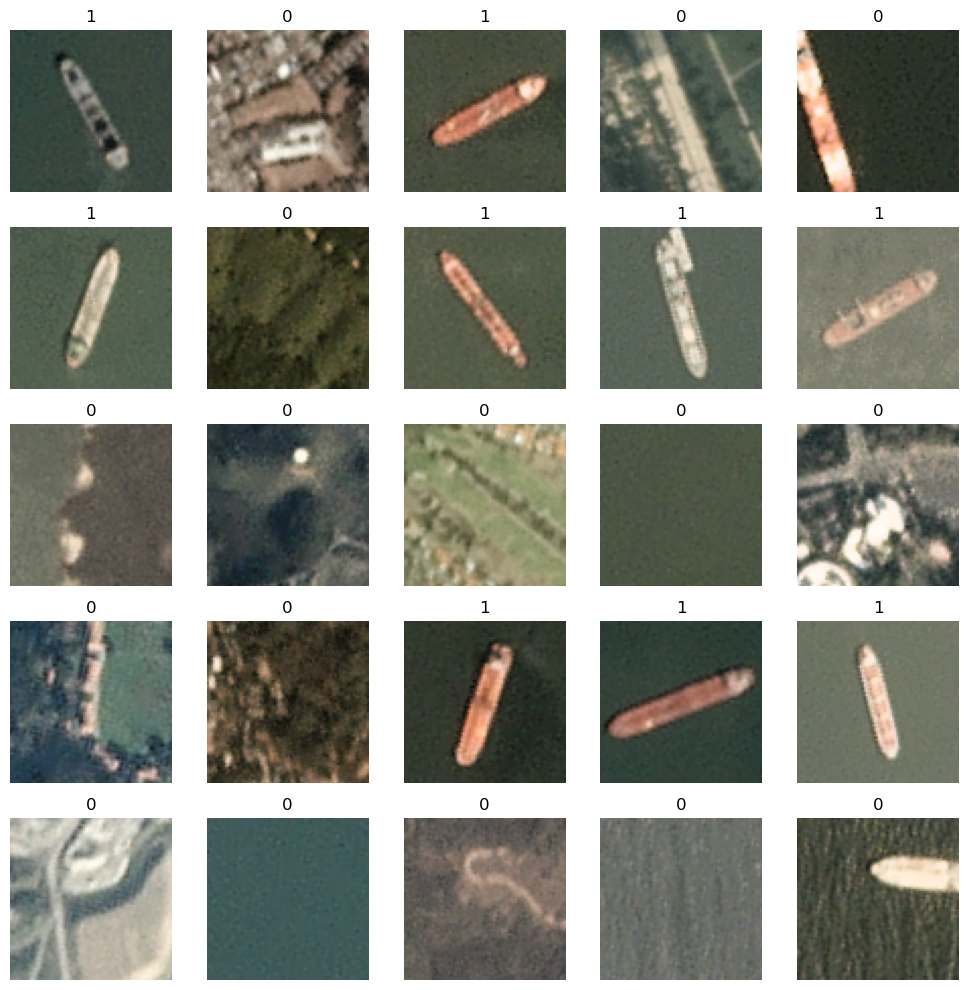

In [7]:
# Visualize the data samples
helper.showData(data[:25], labels[:25])


## Have  look at the data: Examine the image/label pairs

Rather than viewing the examples in random order, let's group them by label.

Perhaps we will learn something about the characteristics of images that contain ships.

We have loaded and shuffled our dataset, now we will take a look at image/label pairs. 

Feel free to explore the data using your own ideas and techniques.


In [8]:
# Inspect some data (images)
num_each_label = 10

for lab in np.unique(labels):
    # Fetch images with different labels
    X_lab, y_lab = data[ labels == lab ], labels[ labels == lab]
    # Display images
    fig = helper.showData( X_lab[:num_each_label], [ str(label) for label in y_lab[:num_each_label] ], cmap="gray")
    _ = fig.suptitle("Label: "+  str(lab), fontsize=14)
    print("\n\n")

# Make sure the features are in the range [0,1]  

**Warm up exercise:** When we want to train on image data, the first thing we usually need to do is scaling. 

Since the feature values in our image data are between 0 and 255, to make them between 0 and 1, we need to divide them by 255.  

We also need to consider how to represent our target values
- If there are more than 2 possible target values, One Hot Encoding may be appropriate
    - **Hint**: Lookup `tf.keras.utils.to_categorical`
- If there are only 2 possible targets with values 0 and 1 we can use these targets without further encoding

**Question**
- Set variable `X` to be our **color** (3 channels) examples (`data`), but with values in the range [0,1]
- Set variable `y` to be the representation of our target values



In [9]:
# Scale the data
# Assign values for X, y
#  X: the array of features
#  y: the array of labels
# The length of X and y should be identical and equal to the length of data.
from tensorflow.keras.utils import to_categorical
X, y = np.array([]), np.array([])
data, labels = helper.getData()  
X = data / 255
y = labels
print(f"X shape: {X.shape}, y shape: {y.shape}")
# YOUR CODE HERE
#raise NotImplementedError()

X shape: (4000, 80, 80, 3), y shape: (4000,)


In [10]:
# Check if your solution is right 

assert X.shape == (4000, 80, 80, 3)
assert ( (y.shape == (4000,)) or (y.shape == (4000,1)) )


# Split data into training data and testing data
To train and evaluate a model, we need to split the original dataset into
a training subset (in-sample) and a test subset (out of sample).

We will do this for you in the cell below.

**DO NOT** shuffle the data until after we have performed the split into train/test sets
- We want everyone to have the **identical** test set for grading
- Do not change this cell



In [11]:
# Split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Save X_train, X_test, y_train, y_test for final testing
if not os.path.exists('./data'):
    os.mkdir('./data')
np.savez_compressed('./data/train_test_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)


# Create a simple CNN model 

**Question:** Create a Keras Sequential model:
- With a single Convolutional Layer providing the number of features given in variable `num_conv_features1` indicated below.
    - You may choose your own kernel size
    - Use same padding
- Feeding a head layer implementing Classification  

Please name your Convolutional layer "CNN_1" and your Dense layer (head layer) "dense_head"

Set variable `model0` to be a Keras `Sequential` model object that implements your model.

**Hints:**
1. The `input shape` argument of the first layer should be the shape of a single example, which should be 3-dimensional. We don't need to flatten the data before feeding the Convolutional layer.
2. What is the shape of the output of the Convolutional Layer ? What should be the shape of the input to the Classification head ?
    - You may want to flatten the output of the Convolutional layer before feeding the Classification head.
3. The number of units in your head layer 
    - Depends on how you represented the target
    - It should be equal to the final dimension of  `y`

4. Activation function for the head layer: Since this is a classification problem
    - Use  `sigmoid` if your target's final dimension equals 1
    - Use  `softmax` if your target's final dimension is greater than 1

Think about the number of parameters in this model and whether
it is likely to be prone to overfitting. 
If you feel the need:

- A Dropout layer maybe helpful to prevent overfitting and accelerate your training process. 
    - If you want to use a Dropout layer, you can use `Dropout()`, which is in  `tensorflow.keras.layers`. 



In [12]:
# Set model0 equal to a Keras Sequential model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout

num_conv_features1 = 32
model0 = Sequential()
model0.add(Conv2D(
        num_conv_features1,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=(80, 80, 3),
        name="CNN_1",
    )
)
model0.add(Flatten())
model0.add(Dense(1, activation="sigmoid", name="dense_head"))

# YOUR CODE HERE
#raise NotImplementedError()

model0.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CNN_1 (Conv2D)                  │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 204800)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │       204,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,697 (803.50 KB)

 Trainable params: 205,697 (803.50 KB)

 Non-trainable params: 0 (0.00 B)

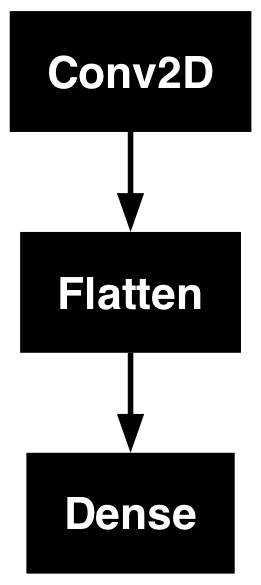

In [13]:
# Plot your model
plot_model(model0)

## Train model


**Question:**

Now that you have built your first model, you will compile and train it. The requirements are as follows:

- Split the **training** examples `X_train, y_train` again !
    - 80% will be used for training the model
    - 20% will be used as validation (out of sample) examples
    - Use `train_test_split()` from `sklearn` to perform this split
        -  Set the `random_state` parameter of `train_test_split()` to be 42

- Loss function: 
    - `binary_crossentropy` if your target is one-dimensional
    - `categorical_crossentropy`if your target is One Hot Encoded
- Metric: "accuracy"
- Use the value in variable `max_epochs` as the number of epochs for training

- Plot your training results using the`plotTrain` method described in the Student API above.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7488 - loss: 0.9247 - val_accuracy: 0.9062 - val_loss: 0.2188
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9251 - loss: 0.1935 - val_accuracy: 0.9300 - val_loss: 0.1606
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9551 - loss: 0.1327 - val_accuracy: 0.9362 - val_loss: 0.1494
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9643 - loss: 0.1067 - val_accuracy: 0.9463 - val_loss: 0.1343
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9649 - loss: 0.0962 - val_accuracy: 0.9538 - val_loss: 0.1157
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9732 - loss: 0.0761 - val_accuracy: 0.9538 - val_loss: 0.1134
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9730 - loss: 0.0757 - val_accuracy: 0.9287 - val_loss: 0.1595
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9782 - loss: 0.0671 - val_accu

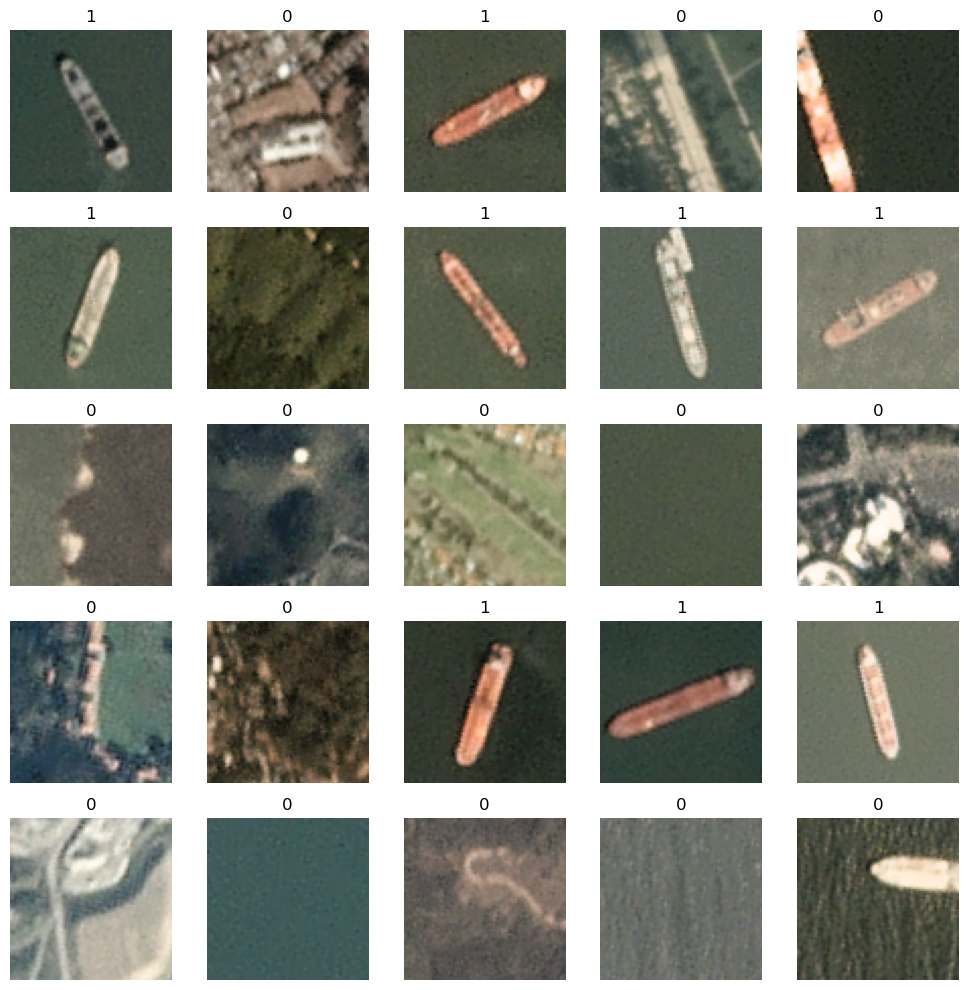

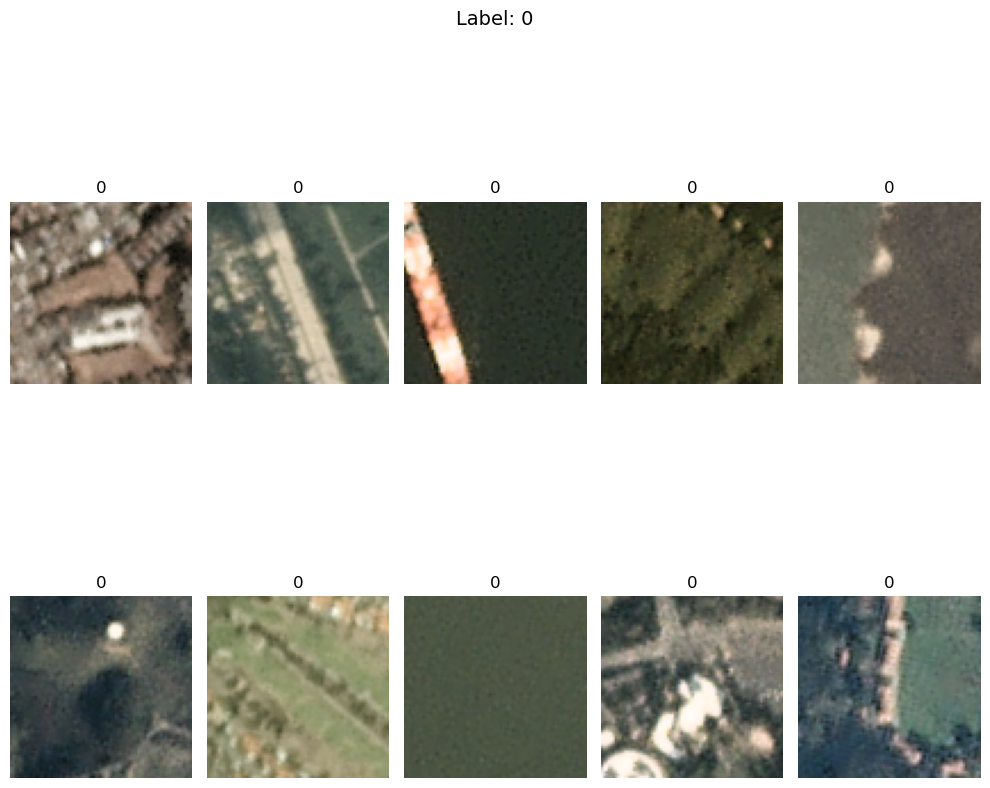

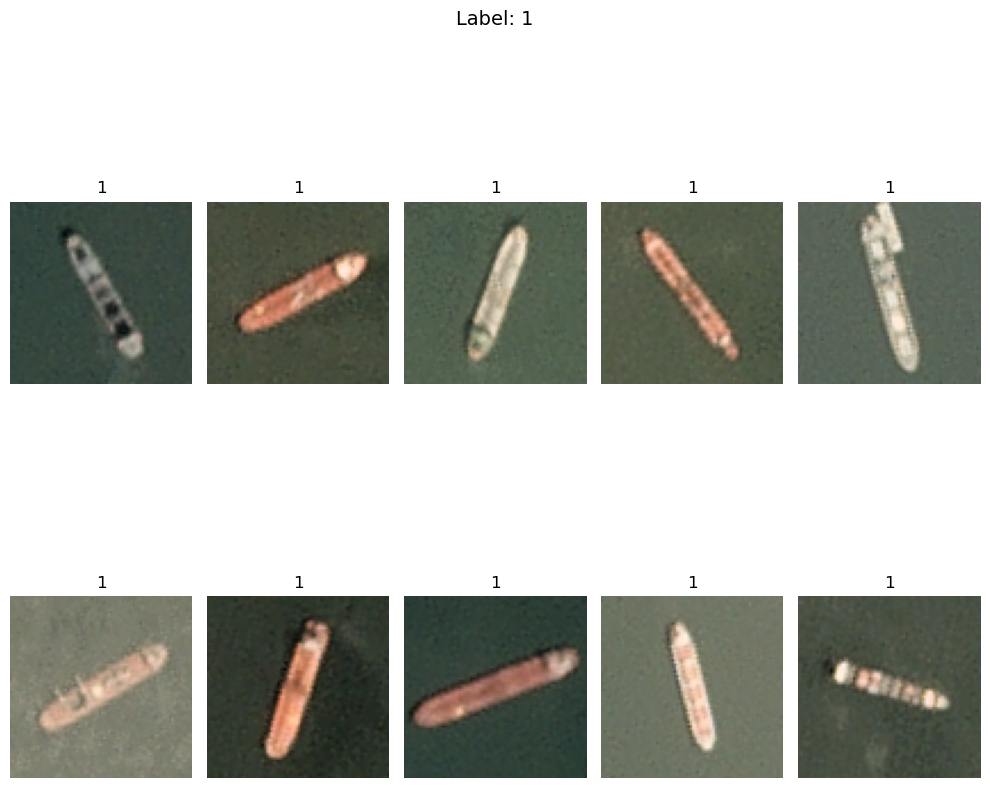

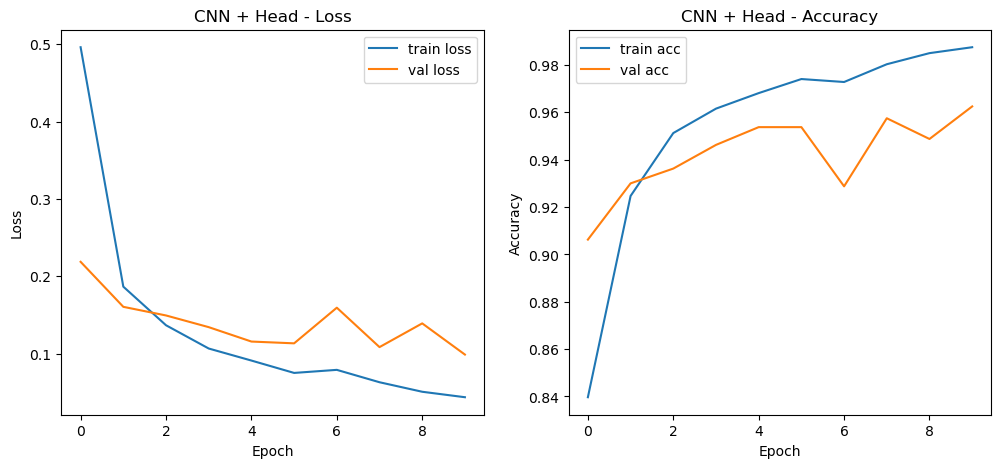

In [14]:
model_name0 = "CNN + Head"
max_epochs = 10
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
loss_function = "binary_crossentropy"
model0.compile(optimizer="adam", loss=loss_function, metrics=["accuracy"])
history0 = model0.fit(X_train, y_train, epochs=max_epochs, validation_data=(X_valid, y_valid))
def plotTrain(history, model_name="Model"):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].plot(history.history["loss"], label="train loss")
    axs[0].plot(history.history["val_loss"], label="val loss")
    axs[0].set_title(f"{model_name} - Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[1].plot(history.history["accuracy"], label="train acc")
    axs[1].plot(history.history["val_accuracy"], label="val acc")
    axs[1].set_title(f"{model_name} - Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    plt.show()
plotTrain(history0,model_name0)
# YOUR CODE HERE
#raise NotImplementedError()

## How many weights in the model ?

**Question:** 

Calculate the number of parameters in your model.  

Set variable `num_parameters0` to be equal to the number of parameters in your model.

**Hint:** The model object may have a method to help you ! Remember that Jupyter can help you find the methods that an object implements.



In [15]:
# Set num_parameters2 equal to the number of weights in the model
#num_parameters0 = None
# YOUR CODE HERE
#raise NotImplementedError()
num_parameters0 = model0.count_params()
print("Parameters number in model0: ", num_parameters0)

Parameters number in model0:  205697


## Evaluate the model

**Question:**

We have trained our model. We now need to  evaluate the model using the test dataset created in an earlier cell.

Please store the model score in a variable named `score0`.   

**Hint:** The model object has a method  `evaluate`.  Use that to compute the score.




In [16]:
#score0 = []
score0 = model0.evaluate(X_test, y_test, verbose=1)
# YOUR CODE HERE
#raise NotImplementedError()

print("{n:s}: Test loss: {l:3.2f} / Test accuracy: {a:3.2f}".format(n=model_name0, l=score0[0], a=score0[1]))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9531 - loss: 0.0956 
CNN + Head: Test loss: 0.11 / Test accuracy: 0.95


Your test accuracy should be around 0.9

## Save the trained model0 and history for submission

Your fitted model can be saved for later use
- In general: so you can resume training at a later time
- In particular: to allow us to grade it !

Execute the following cell to save your model, which you will submit to us for grading.

In [17]:
helper.saveModel(model0, model_name0)
helper.saveHistory(history0, model_name0)

Model saved in ./models/CNN + Head.keras; submit with your assignment.


In [18]:
## Restore the model (make sure that it works)
model_loaded = helper.loadModel(model_name0)
score_loaded = model_loaded.evaluate(X_test, y_test, verbose=0)

assert score_loaded[0] == score0[0] and score_loaded[1] == score0[1]

# Create a model with 4 Convolutional layers

**Question:** 

We will now create a model with more Convolutional layers.
- Use **4** Convolutional layers.
    - You may choose your own kernel size
    - Use full padding
    - ReLU activation functions for the Convolutional layers

    - Each of the first two Convolutional layers should have the number of features given in variable `num_conv_features1` indicated below
        - Please name thee layers "CNN_1" and "CNN_2"
    - Each of the last two Convolutional layers should have the number of features given in variable `num_conv_features2` indicated below
        - Please name thee layers "CNN_3" and "CNN_4"
- Insert a `MaxPooling` layer after every two Convolutional layers (e.g., after CNN_2 and CNN_4)
    - to reduce each spatial dimension by a factor of 2  

- Please name your head layer "dense_head". 

Set variable `model1` to be a Keras `Sequential` model object that implements your model.

**Hints:**
- Don't forget to flatten the output of the layer feeding the Classification head 
- A Dropout layer maybe helpful to prevent overfitting and accelerate your training process. 


In [19]:
# Set model1 equal to a Keras Sequential model
from tensorflow.keras.layers import Conv2D, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, MaxPooling2D
model1 = None
num_conv_features1 = 32
num_conv_features2 = 64
model1 = Sequential([
    Conv2D(num_conv_features1, kernel_size=(3, 3), padding="same", activation="relu", name="CNN_1", input_shape=X.shape[1:]),
    Conv2D(num_conv_features1, kernel_size=(3, 3), padding="same", activation="relu", name="CNN_2"),
    MaxPooling2D(pool_size=(2, 2), name="MaxPool_1"),
    Conv2D(num_conv_features2, kernel_size=(3, 3), padding="same", activation="relu", name="CNN_3"),
    Conv2D(num_conv_features2, kernel_size=(3, 3), padding="same", activation="relu", name="CNN_4"),
    MaxPooling2D(pool_size=(2, 2), name="MaxPool_2"),
    Flatten(),
    Dropout(0.2),  
    Dense(1, activation="sigmoid", name="dense_head")
])

model1.summary()

# YOUR CODE HERE
#raise NotImplementedError()

model1.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CNN_1 (Conv2D)                  │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_2 (Conv2D)                  │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_3 (Conv2D)                  │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_4 (Conv2D)                  │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │        25,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,169 (356.13 KB)

 Trainable params: 91,169 (356.13 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CNN_1 (Conv2D)                  │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_2 (Conv2D)                  │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_3 (Conv2D)                  │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_4 (Conv2D)                  │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │        25,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,169 (356.13 KB)

 Trainable params: 91,169 (356.13 KB)

 Non-trainable params: 0 (0.00 B)

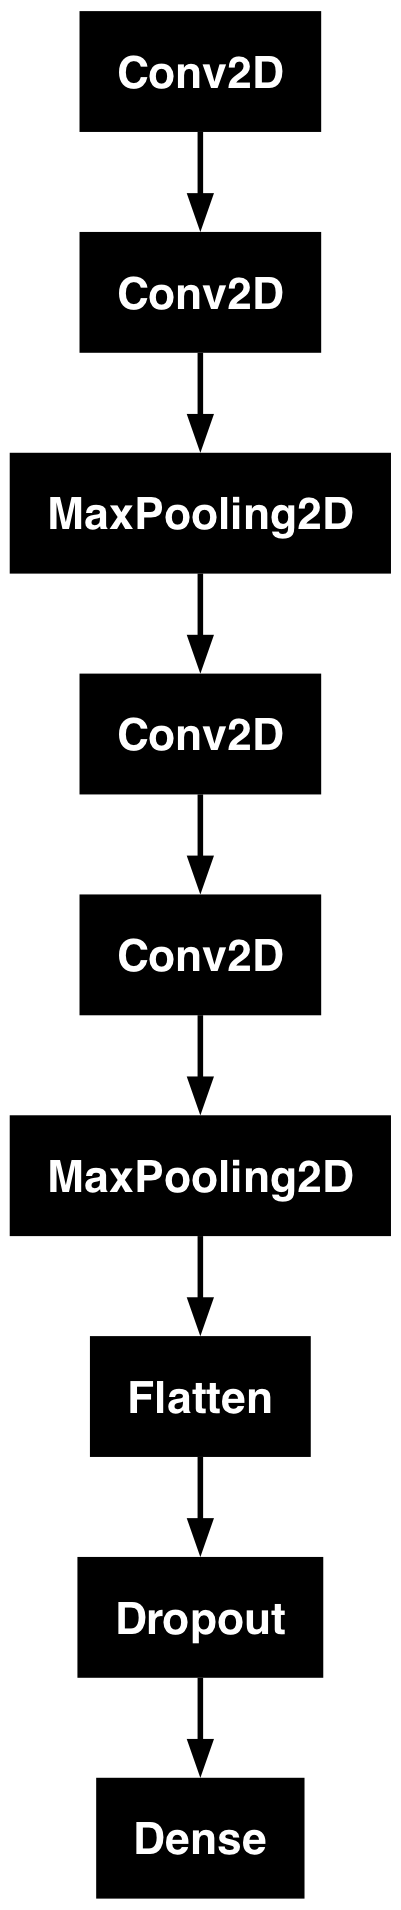

In [20]:
# Plot your model
plot_model(model1)

## Train model

**Question:**

Train your new model following the same instructions as given for training the first model.
- Use the same datasets for training and validation as in your first model
- Use the same Loss function and metrics as in your first model
- **Except**: Save your training results in a variable named `history1`



In [21]:
# Train the model using the API
model_name1 = "4CNNs + Head"
from tensorflow.keras.optimizers import Adam
model1.compile(
    optimizer='adam',
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=max_epochs,
)

helper.plotTrain(history1, model_name1)

# YOUR CODE HERE
#raise NotImplementedError()

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.8142 - loss: 0.4343 - val_accuracy: 0.9112 - val_loss: 0.2168
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.9184 - loss: 0.2004 - val_accuracy: 0.9287 - val_loss: 0.1687
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.9335 - loss: 0.1945 - val_accuracy: 0.9413 - val_loss: 0.1707
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.9533 - loss: 0.1264 - val_accuracy: 0.9525 - val_loss: 0.1344
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.9672 - loss: 0.0960 - val_accuracy: 0.9575 - val_loss: 0.1112
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 145ms/step - accuracy: 0.9713 - loss: 0.0939 - val_accuracy: 0.9700 - val_loss: 0.0959
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.9795 - loss: 0.0602 - val_accuracy: 0.9600 - val_loss: 0.1335
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.9819 - loss: 0

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': '4CNNs + Head model loss'}, xlabel='epoch', ylabel='loss'>,
        <Axes: title={'center': '4CNNs + Head model accuracy'}, xlabel='epoch', ylabel='accuracy'>],
       dtype=object))

## How many weights in this model ?

**Question:** Calculate the number of parameters in your new model.  

Set variable `num_parameters1` to be equal to the number of parameters in your model.



In [22]:
# Set num_parameters3 equal to the number of weights in the model
num_parameters1 = model1.count_params()

# YOUR CODE HERE
#raise NotImplementedError()

print('Parameters number in model1:', num_parameters1)

Parameters number in model1: 91169


## Evaluate the model

Evaluate your new model following the same instructions as given for evaluating the first model.
- **Except**: store the model score in a variable named `score1`.  



In [23]:
score1 = model1.evaluate(X_test, y_test, verbose=1)

# YOUR CODE HERE
#raise NotImplementedError()

print("{n:s}: Test loss: {l:3.2f} / Test accuracy: {a:3.2f}".format(n=model_name1, l=score1[0], a=score1[1]))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9797 - loss: 0.0589
4CNNs + Head: Test loss: 0.09 / Test accuracy: 0.98


Is your test accuracy higher than before ?

# Save your trained model1 and history1

In [24]:
helper.saveModel(model1, model_name1)
helper.saveHistory(history1, model_name1)

Model saved in ./models/4CNNs + Head.keras; submit with your assignment.


## Discussion


You can learn a lot by experimenting.  Some ideas to try:
- Change the kernel size in Convolutional layers
- Compare two different models
    - one using a single Convolutional layer with filter size 5
    - another using two Convolutional layers with filter size 3
- Change the number of features of Convolutional layers
- Experiment with different pooling layers: `MaxPooling2D` and `AveragePooling2D`
- Change the activation function

Observe the effect of each change on the Loss and Accuracy.

Questions to consider:
- How did the number of parameters change between the two models ?
- How did the choice of layer types affect the number of parameters ?


In [25]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, BatchNormalization, LeakyReLU
activation = 'sigmoid'
model_A = Sequential([
    Conv2D(64, kernel_size=(5, 5), padding="same", input_shape=(80, 80, 3), name="CNN_A"),
    BatchNormalization(),                      
    LeakyReLU(alpha=0.1),                     
    AveragePooling2D(pool_size=(5, 5), name="AveragePool_A"),
    Flatten(),
    Dense(1, activation=activation, name="dense_head")
])

model_A.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_A.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CNN_A (Conv2D)                  │ (None, 80, 80, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AveragePool_A                   │ (None, 16, 16, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,505 (84.00 KB)

 Trainable params: 21,377 (83.50 KB)

 Non-trainable params: 128 (512.00 B)

In [31]:
activation = 'sigmoid'
model_B = Sequential([
    Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(80, 80, 3), name="CNN_B1"),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),            
    
    Conv2D(32, kernel_size=(3, 3), padding='same', name="CNN_B2"),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),                        
    
    MaxPooling2D(pool_size=(3, 3), name="MaxPool_B"),
    Flatten(),
    Dense(1, activation=activation, name="dense_head")
])

model_B.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_B.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CNN_B1 (Conv2D)                 │ (None, 80, 80, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_B2 (Conv2D)                 │ (None, 80, 80, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_B (MaxPooling2D)        │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 1)              │        21,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,033 (125.13 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 128 (512.00 B)

In [32]:
history_A = model_A.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.8536 - loss: 0.3632 - val_accuracy: 0.8700 - val_loss: 0.4549
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.9484 - loss: 0.1416 - val_accuracy: 0.8250 - val_loss: 0.3376
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9519 - loss: 0.1253 - val_accuracy: 0.9275 - val_loss: 0.2697
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9588 - loss: 0.1059 - val_accuracy: 0.8925 - val_loss: 0.2232
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.9615 - loss: 0.0935 - val_accuracy: 0.7825 - val_loss: 1.2056
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9788 - loss: 0.0661 - val_accuracy: 0.9312 - val_loss: 0.1802
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9760 - loss: 0.0706 - val_accuracy: 0.8963 - val_loss: 0.3357
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.9826 - loss: 0.0468 - val_accu

In [33]:
history_B = model_B.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.8042 - loss: 1.0670 - val_accuracy: 0.8275 - val_loss: 0.4439
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.9574 - loss: 0.1175 - val_accuracy: 0.8775 - val_loss: 0.3348
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9725 - loss: 0.0870 - val_accuracy: 0.8850 - val_loss: 0.2466
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.9776 - loss: 0.0631 - val_accuracy: 0.9087 - val_loss: 0.1803
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.9789 - loss: 0.0526 - val_accuracy: 0.9575 - val_loss: 0.1215
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.9883 - loss: 0.0372 - val_accuracy: 0.9525 - val_loss: 0.1406
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.9881 - loss: 0.0337 - val_accuracy: 0.9362 - val_loss: 0.2479
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step - accuracy: 0.9866 - loss: 0

In [34]:
def plot_results(history, model_name):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

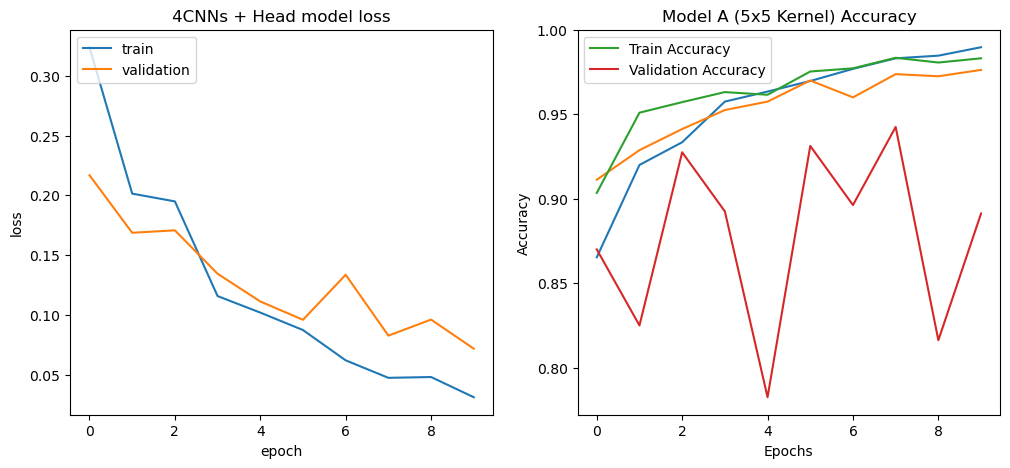

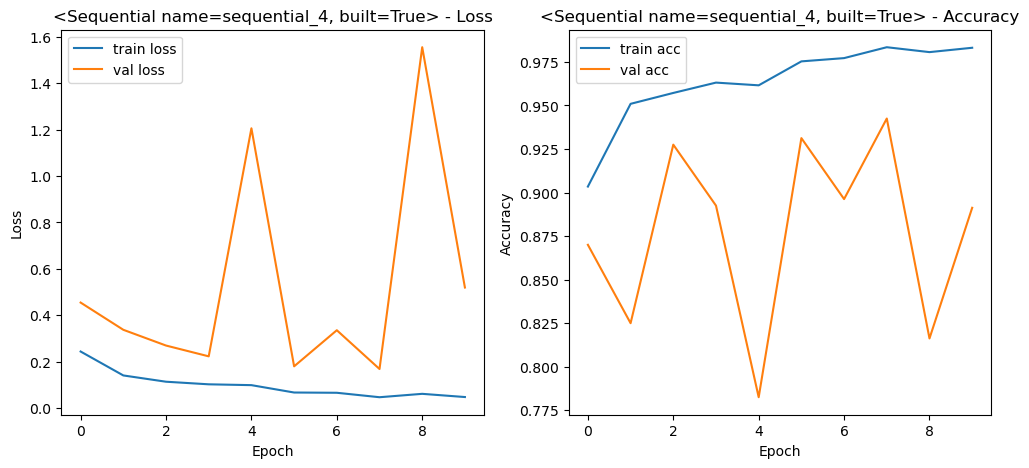

In [35]:
plot_results(history_A, "Model A (5x5 Kernel)")
plotTrain(history_A,model_A)

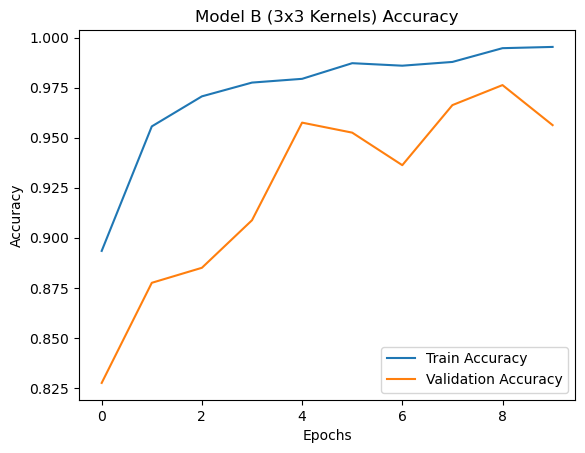

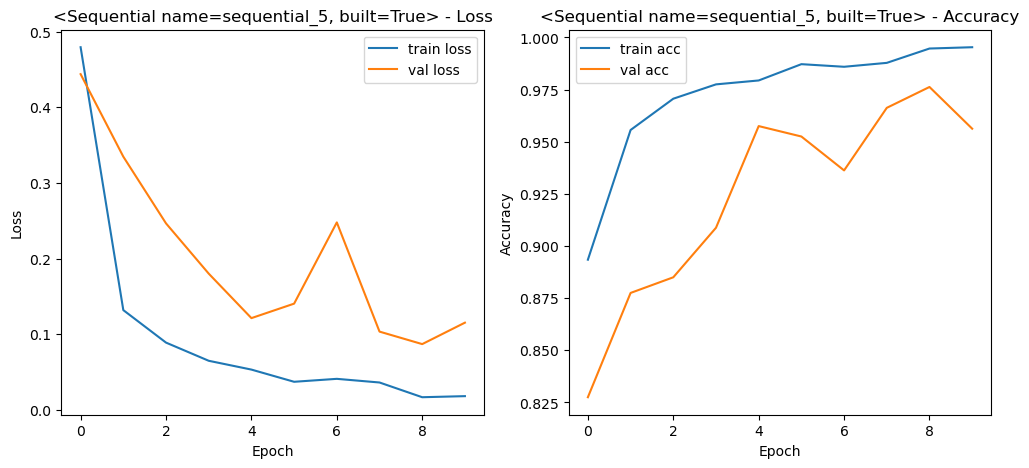

In [36]:
plot_results(history_B, "Model B (3x3 Kernels)")
plotTrain(history_B,model_B)

In [37]:
score_A = model_A.evaluate(X_val, y_val)
score_B = model_B.evaluate(X_val, y_val)
print(f"Model A - Loss: {score_A[0]:.2f}, Accuracy: {score_A[1]:.2f}")
print(f"Model B - Loss: {score_B[0]:.2f}, Accuracy: {score_B[1]:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8894 - loss: 0.5128
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9641 - loss: 0.1049
Model A - Loss: 0.52, Accuracy: 0.89
Model B - Loss: 0.12, Accuracy: 0.96


The notebook softmax gives very poor results

For Model0:
A simple model with 1 Conv2D layer, and a dense output layer; Parameters used for the CNN layer were relu for the Conv2D layer and     sigmoid for the dense layer. During compilation the loss function used was binary cross entropy with adam as the optimizer. The test accuracy was 94% with a loss of 0.16. The number of parameters were 209,697. 

For Model1:
A deeper model with 4 Conv2D layers, 2 MaxPooling layers, dropout, and a dense head; achieved improved accuracy with test accuracy being 98% with a loss of 0.10. The paramters were similar for the Conv2D and the dense layer. The 2 MaxPooling2D layers had a pool size of (2,2) and the dense layer with activation function used was sigmoid. Parameter count: 91,169. The added depth and filters helped extract better features, though it required more training time and memory. 

For Model_A and Model_B:
Both models were evaluated under similar conditions, but Model_B significantly outperformed Model_A in terms of accuracy and loss. Despite having a higher parameter count, Model_B achieved a test accuracy of 96% with a low loss of 0.10, while Model_A reached only 89% accuracy with a much higher loss of 0.52. The choice between AveragePooling2D in Model_A and MaxPooling2D in Model_B contributed to differences in feature retention, but the more impactful factor was Model_B’s use of two convolutional layers, which preserved spatial information longer and allowed for richer feature extraction.

Activation function choice also played a crucial role — Sigmoid consistently performed better than Softmax for this dataset. Changes to kernel size did not have a significant effect.
Despite Model_A having fewer parameters (21,505) than Model_B (32,033), its performance was weaker, emphasizing that layer depth and feature extraction quality often matter more than just parameter count.

Why Model 0 has more parameters:
The Flatten() layer directly after the first Conv2D layer passes a large number of units to the Dense layer.
This results in a very large Dense layer, which is where most of the parameters come from.
Why Model 1 has fewer parameters despite more Conv2D layers:
The two MaxPooling2D layers progressively reduce the feature map dimensions (height and width), so by the time data is flattened, the input to the Dense layer is much smaller.
Even with 4 Conv2D layers, the feature extraction is done with smaller filters and intermediate pooling, reducing the final number of inputs to the dense head layer.

How did the number of parameters change between the two models?
Model_A and Model_B have a similar number of parameters — 21,505 and 32,033 respectively — with Model_B having around 10,500 more. Despite Model_A using a larger kernel size and more filters in a single convolutional layer, the increased depth and architecture of Model_B contribute more to its parameter count.

How did the choice of layer types affect the number of parameters?
Model_B uses two Conv2D layers with 32 filters each and applies pooling later, preserving more spatial resolution across layers. This increases the size of the flattened feature map and results in a larger Dense layer, which significantly contributes to the total parameter count. Model_A, on the other hand, uses a single Conv2D layer with 64 filters followed by early pooling with a large pool size, which reduces the spatial dimensions aggressively. This leads to fewer features being passed to the Dense layer, and consequently fewer overall parameters. Since activation functions like ReLU and LeakyReLU are parameter-free, they do not affect parameter count, and the difference is primarily due to layer stacking, pooling position, and output volume size before the Dense layer.

In [38]:
num_parametersA = model_A.count_params()
num_parametersA

21505

In [39]:
num_parametersB=model_B.count_params()
num_parametersB

32033